In [1]:
import os
import sys; sys.path.append(os.path.abspath('..'))

from src.environment import WarehouseEnv
from src.planning.fsm_planner import FSMAutomaton
from src.utils.visualization import EnvironmentVisualizer, FunctionVisualizer, create_evaluation_animation
import yaml
from src.utils.buffer import ReplayBuffer

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

with open("../config/warehouse_v1.yaml", 'r') as f:
    config = yaml.safe_load(f)
env = WarehouseEnv(config)
fsm = FSMAutomaton(start_pos = config['fsm']['start_state'], goal_pos = config['fsm']['goal_state'], config=config)

# now let's inspect the data generated in pretrain_data.pkl 

# Load the pretrain data directly from pickle file: And LOAD the variables
data_path = "../" + config['data_gen']['data_path']
with open(data_path, 'rb') as f:
    data = pickle.load(f)

states = data['states']
actions = data['actions']
next_states = data['next_states']
subgoals = data['subgoals']
rewards = data['rewards']
dones = data['dones']
h_stars = data['h_stars']
v_stars = data['v_stars']
num_transitions = len(states)

print(f"=== Data Inspection: {data_path} ===\n")
print(f"Total transitions: {num_transitions}")
print(f"State dimension: {states.shape[1]}")
print(f"Action dimension: {actions.shape[1]}")
print(f"Subgoal dimension: {subgoals.shape[1]}\n")

# Basic statistics
print("=== Safety Statistics ===")
safe_count = np.sum(h_stars > 0)
unsafe_count = np.sum(h_stars <= 0)
collision_count = np.sum(dones > 0)
print(f"Safe states (h* > 0): {safe_count} ({100*safe_count/num_transitions:.1f}%)")
print(f"Unsafe states (h* <= 0): {unsafe_count} ({100*unsafe_count/num_transitions:.1f}%)")
print(f"Collisions (done=True): {collision_count} ({100*collision_count/num_transitions:.1f}%)\n")

print("=== Value Statistics ===")
print(f"h* (safety): min={h_stars.min():.3f}, max={h_stars.max():.3f}, mean={h_stars.mean():.3f}")
print(f"v* (feasibility): min={v_stars.min():.3f}, max={v_stars.max():.3f}, mean={v_stars.mean():.3f}\n")


Waypoint positions: [array([1.38049257, 1.45648839]), array([1.91627456, 1.19592648]), array([2.41787597, 1.50625058]), array([2.80073553, 1.95173404]), array([3.36502386, 2.0474904 ]), array([3.92130378, 1.86629338]), array([4.31288672, 2.30809337]), array([4.40135017, 2.88725617]), array([4.97002647, 3.01018754]), array([5.52946787, 3.14644578]), array([5.49169472, 3.73575013]), array([6.00783393, 4.01006165]), array([6.51064646, 3.71544987]), array([6.87683883, 4.15354412]), array([6.71213335, 4.6964386 ]), array([6.52340506, 5.23703546]), array([6.74703533, 5.79085196]), array([6.88302007, 6.3364335 ]), array([6.46491511, 6.727223  ]), array([6.84305548, 7.1512167 ]), array([7.4134914 , 7.14489103]), array([7.57439664, 7.70739618]), array([8.0474048 , 7.98870097]), array([8.30475274, 8.48793309]), array([8.74852604, 8.75996203]), array([9.27962774, 8.50402512]), array([9.74401823, 8.83798132])]
=== Data Inspection: ../data/pretrain_data.pkl ===

Total transitions: 30000
State dimen


About the state

- $\theta$ (Heading Angle) = The orientation of the robot in the 2D plane, measured counter-clockwise from the positive X-axis.
- Linear velocity = The robot's forward speed along its current heading. The model assumes a non-holonomic constraint (it cannot slide sideways) = Determines the rate of change of $x$ and $y$.


For the control input u

- a = linear acceleration = The rate of change of the linear velocity $v$. Controls the forward/backward thrust (speed change). 
- $\dot{v} = a$.
- The rate of change of the heading angle $\theta$ (also called $\dot{\theta}$). Controls the turning rate (steering). $\dot{\theta} = \omega$.

- Step 1: Generate data for training
- Step 2: Pre-training

## Understanding Feasibility (v*)

### What is Feasibility?

**Feasibility (v*)** measures how far a state is from reaching a given subgoal. 

We use distance to subgoal as a bootstrap for CLF candidate in our scenario:

$$v^*(s, g) = ||p - g||^2$$

where:
- $p$ is the robot's position (first 2 dimensions of state)
- $g$ is the subgoal position
- The value is the **squared Euclidean distance** to the subgoal

- **Lower v* values** = closer to the subgoal = more feasible
- **Higher v* values** = farther from the subgoal = less feasible
- **v* ≈ 0** = at the subgoal (within epsilon threshold, typically 0.25 = 50cm radius)

### How it was Pre-trained

1. **Ground Truth Generation**: During data generation, v* is computed directly from the squared distance between state position and subgoal position.

2. **Pre-training Phase** (Phase 1):
   - The CLF (Control Lyapunov Function) network `V_ψ(s, g)` is trained to predict v* using **MSE loss**:
     $$L_{pretrain} = ||V_ψ(s, g) - v^*(s, g)||^2$$
   - This "anchors" the CLF to match the ground truth distance function
   - Training uses batches from the collected data for 50 epochs

3. **Main Training Phase** (Phase 2):
   - After pretraining, the CLF is fine-tuned with constraint-based losses:
     - **Goal loss**: Forces V_ψ(s, g) ≈ 0 when at goal (v* ≤ ε)
     - **Constraint loss**: Enforces decrease condition: V(s_{k+1}) ≤ (1-β)V(s_k) + δ
     - **Positivity loss**: Ensures V(s) > 0 for non-goal states
   - This ensures the CLF satisfies Control Lyapunov Function properties for stability

### Why Feasibility Matters

The CLF (feasibility critic) ensures the policy makes progress toward subgoals. During training, the actor is penalized if actions don't decrease the CLF value, forcing the agent to make progress toward goals while maintaining safety (via the CBF).



=== Sample Transitions ===
[20542 22458 15519 11141 26511]

Transition 20542:
  State: [2.96, 8.00, ...]
  Action: [-0.349, -1.085]
  Next State: [2.96, 8.00, ...]
  Subgoal: [10.50, 8.50]
  h* (safety): 0.348 (SAFE)
  v* (feasibility): 57.092
  Done: 0.0

Transition 22458:
  State: [0.40, 8.52, ...]
  Action: [-1.992, 1.293]
  Next State: [0.40, 8.52, ...]
  Subgoal: [10.50, 8.50]
  h* (safety): 0.246 (SAFE)
  v* (feasibility): 102.091
  Done: 0.0

Transition 15519:
  State: [5.08, 2.39, ...]
  Action: [2.294, 1.324]
  Next State: [5.08, 2.37, ...]
  Subgoal: [6.00, 5.00]
  h* (safety): 0.345 (SAFE)
  v* (feasibility): 7.761
  Done: 0.0

Transition 11141:
  State: [4.10, 8.78, ...]
  Action: [1.357, -1.303]
  Next State: [4.11, 8.79, ...]
  Subgoal: [10.50, 8.50]
  h* (safety): 1.064 (SAFE)
  v* (feasibility): 40.881
  Done: 0.0

Transition 26511:
  State: [3.84, 7.92, ...]
  Action: [-2.585, 1.055]
  Next State: [3.84, 7.92, ...]
  Subgoal: [6.00, 5.00]
  h* (safety): 0.267 (SAFE)
 

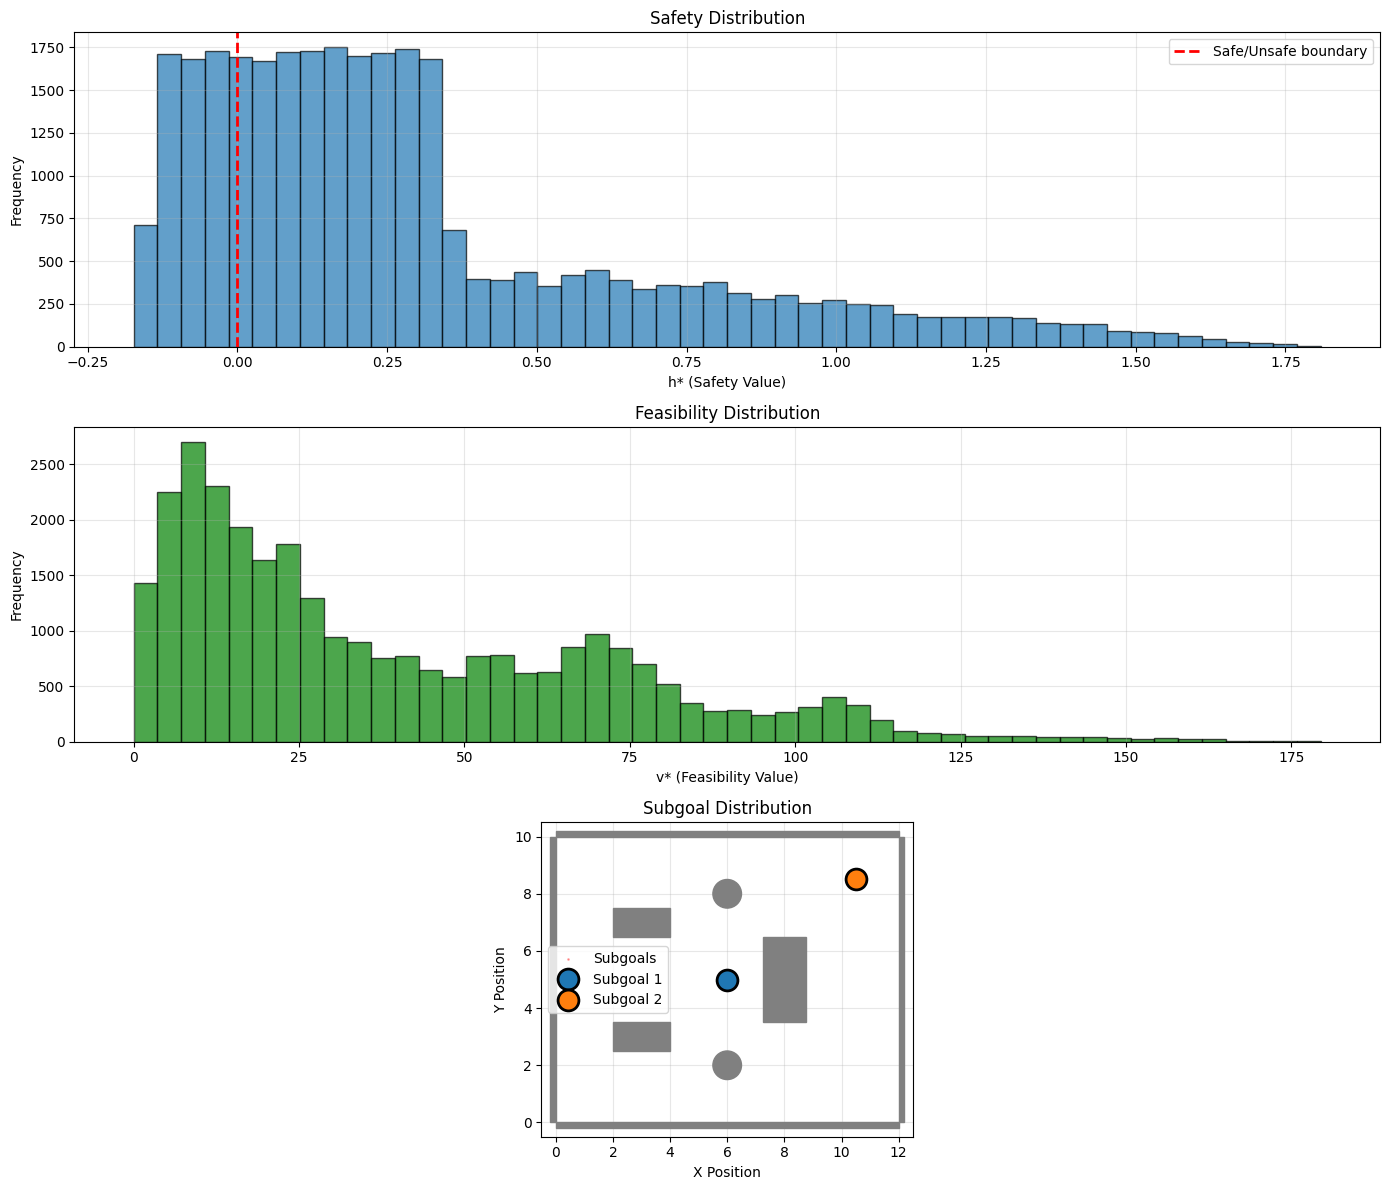

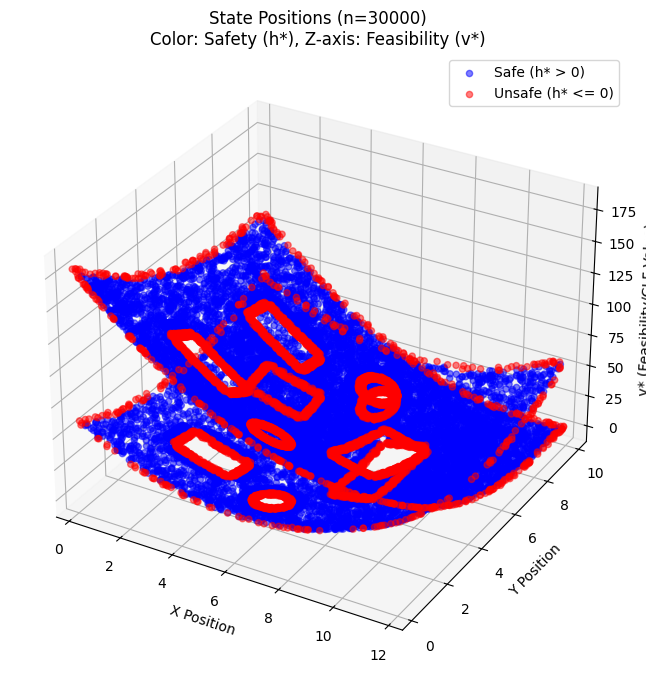

In [2]:
import numpy as np

print("\n=== Sample Transitions ===")
sample_indices = np.random.choice(num_transitions, min(5, num_transitions), replace=False)
print(sample_indices)

for idx in sample_indices:
    s = states[idx]
    a = actions[idx]
    s_next = next_states[idx]
    g = subgoals[idx]
    h_star_val = h_stars[idx][0]
    v_star_val = v_stars[idx][0]
    done = dones[idx][0]
    print(f"\nTransition {idx}:")
    print(f"  State: [{s[0]:.2f}, {s[1]:.2f}, ...]")
    print(f"  Action: [{a[0]:.3f}, {a[1]:.3f}]")
    print(f"  Next State: [{s_next[0]:.2f}, {s_next[1]:.2f}, ...]")
    print(f"  Subgoal: [{g[0]:.2f}, {g[1]:.2f}]")
    print(f"  h* (safety): {h_star_val:.3f} {'(SAFE)' if h_star_val > 0 else '(UNSAFE)'}")
    print(f"  v* (feasibility): {v_star_val:.3f}")
    print(f"  Done: {done}")

# Subgoal distribution
print("=== Subgoal Distribution ===")
subgoals_unique = np.unique(subgoals, axis=0)

print(f"Unique subgoals: {len(subgoals_unique)}")
for i, sg in enumerate(subgoals_unique):
    count = np.sum(np.all(subgoals == sg, axis=1))
    print(f"  Subgoal {i+1}: {sg} ({count} samples, {100*count/num_transitions:.1f}%)")

# Visualizations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
from src.utils.visualization import FunctionVisualizer

f = FunctionVisualizer(env)

# axes is a 2D ndarray only if you specify more than one row/col; with (1,3) it's 1D (shape [3]), so index as axes[0], axes[1], axes[2]
f.safety_distribution(h_stars, axes[0])
f.feasibility_distribution(v_stars, axes[1])
f.subgoal_positions(subgoals, env, subgoals_unique, axes[2])
f.state_positions(states, env, h_stars, v_stars)

In [ ]:
import torch
from src.core.policy import SubgoalConditionedPolicy

nn_config = config['nn']
train_config = config['train']

# One trial
env = WarehouseEnv(config)
fsm = FSMAutomaton( # NOTE: fsm has the waypoints from the RRT currently
            start_pos=np.array(config['fsm']['start_state']),
            goal_pos=np.array(config['fsm']['goal_state']),
            config=config
    )
buffer = ReplayBuffer(
        state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
        subgoal_dim=nn_config['subgoal_dim'], max_size=train_config['buffer_size']
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = SubgoalConditionedPolicy(
        state_dim=nn_config['state_dim'], subgoal_dim=nn_config['subgoal_dim'],
        action_dim=nn_config['action_dim'], hidden_dims=nn_config['hidden_dims'],
        a_max=env.a_max, omega_max=env.omega_max).to(device)


Waypoint positions: [array([1.38049257, 1.45648839]), array([1.91627456, 1.19592648]), array([2.41787597, 1.50625058]), array([2.80073553, 1.95173404]), array([3.36502386, 2.0474904 ]), array([3.92130378, 1.86629338]), array([4.31288672, 2.30809337]), array([4.40135017, 2.88725617]), array([4.97002647, 3.01018754]), array([5.52946787, 3.14644578]), array([5.49169472, 3.73575013]), array([6.00783393, 4.01006165]), array([6.51064646, 3.71544987]), array([6.87683883, 4.15354412]), array([6.71213335, 4.6964386 ]), array([6.52340506, 5.23703546]), array([6.74703533, 5.79085196]), array([6.88302007, 6.3364335 ]), array([6.46491511, 6.727223  ]), array([6.84305548, 7.1512167 ]), array([7.4134914 , 7.14489103]), array([7.57439664, 7.70739618]), array([8.0474048 , 7.98870097]), array([8.30475274, 8.48793309]), array([8.74852604, 8.75996203]), array([9.27962774, 8.50402512]), array([9.74401823, 8.83798132])]


In [ ]:
fsm.waypoint_positions

[array([1.38049257, 1.45648839]),
 array([1.91627456, 1.19592648]),
 array([2.41787597, 1.50625058]),
 array([2.80073553, 1.95173404]),
 array([3.36502386, 2.0474904 ]),
 array([3.92130378, 1.86629338]),
 array([4.31288672, 2.30809337]),
 array([4.40135017, 2.88725617]),
 array([4.97002647, 3.01018754]),
 array([5.52946787, 3.14644578]),
 array([5.49169472, 3.73575013]),
 array([6.00783393, 4.01006165]),
 array([6.51064646, 3.71544987]),
 array([6.87683883, 4.15354412]),
 array([6.71213335, 4.6964386 ]),
 array([6.52340506, 5.23703546]),
 array([6.74703533, 5.79085196]),
 array([6.88302007, 6.3364335 ]),
 array([6.46491511, 6.727223  ]),
 array([6.84305548, 7.1512167 ]),
 array([7.4134914 , 7.14489103]),
 array([7.57439664, 7.70739618]),
 array([8.0474048 , 7.98870097]),
 array([8.30475274, 8.48793309]),
 array([8.74852604, 8.75996203]),
 array([9.27962774, 8.50402512]),
 array([9.74401823, 8.83798132])]

This cell implements the online training

In [4]:
from src.core.models import EnsembleDynamicsModel
from src.core.critics import CBFNetwork, CLFNetwork
import torch.optim as optim
from tqdm import tqdm
from scripts.hpo_trainer import compute_actor_loss

policy_net = SubgoalConditionedPolicy(
        state_dim=nn_config['state_dim'], subgoal_dim=nn_config['subgoal_dim'],
        action_dim=nn_config['action_dim'], hidden_dims=nn_config['hidden_dims'],
        a_max=env.a_max, omega_max=env.omega_max # Pass both maxes
).to(device)

cbf_net = CBFNetwork(
    state_dim=nn_config['state_dim'], hidden_dims=nn_config['hidden_dims']
).to(device)

clf_net = CLFNetwork(
    state_dim=nn_config['state_dim'], subgoal_dim=nn_config['subgoal_dim'],
    hidden_dims=nn_config['hidden_dims']
).to(device)

dynamics_net = EnsembleDynamicsModel(
    state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
    hidden_dims=nn_config['hidden_dims'], num_ensemble=nn_config['num_ensemble']
).to(device)

if train_config['load_anchored_models']:
    cbf_net.load_state_dict(torch.load("../" + train_config['anchored_cbf_path'], map_location=device))
    clf_net.load_state_dict(torch.load("../" + train_config['anchored_clf_path'], map_location=device))
    print("Successfully loaded pre-trained CBF and CLF models.")



Successfully loaded pre-trained CBF and CLF models.


/Users/matthewtaruno/Dev/long-horizon/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
policy_optim = optim.Adam(policy_net.parameters(), lr=train_config['lr_actor'])
cbf_optim = optim.Adam(cbf_net.parameters(), lr=train_config['lr_critic'])
clf_optim = optim.Adam(clf_net.parameters(), lr=train_config['lr_critic'])
dynamics_optim = optim.Adam(dynamics_net.parameters(), lr=train_config['lr_dynamics'])

In [9]:

fsm.get_current_subgoal()

array([1.38049257, 1.45648839])


This is the main training loop where co-training happens.



In [ ]:

print(f"--- Starting Main Training (Algorithm 2) ---")
global_step = 0

# Set networks to training mode
policy_net.train()
cbf_net.train()
clf_net.train()
dynamics_net.train()

# Cache action scaling tensor for efficiency
action_scale = torch.tensor([env.a_max, env.omega_max], device=device, dtype=torch.float32)

# 3. Run Training Loop
episode_iterator = tqdm(range(train_config['num_episodes'])) # Re-enabled tqdm

for episode in episode_iterator:
    fsm.reset()
    s_nn = env.reset(start_pos=fsm.start_pos)
    episode_ended = False
    
    g = fsm.get_current_subgoal() # This is waypoint_1
    for t in range(train_config['max_episode_length']):
        global_step += 1
        with torch.no_grad():
            s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
            g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
            a_det_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
        
        exploration_noise = train_config['exploration_noise']
        # Add noise to the [-1, 1] action
        a_unscaled = a_det_unscaled + np.random.normal(0, exploration_noise, size=nn_config['action_dim'])
        a_unscaled = np.clip(a_unscaled, -1.0, 1.0)
        
        # Scale action for the environment
        a_scaled = a_unscaled * np.array([env.a_max, env.omega_max])
        
        s_next_nn, _, done, info = env.step(a_scaled)
        v_star = env.get_ground_truth_feasibility(s_next_nn, g)
        collision_penalty = 100.0 if info['is_collision'] else 0.0
        r = -np.sqrt(v_star) - collision_penalty 
        fsm_state = fsm.transition(s_next_nn)
        done = info['is_collision']
        
        buffer.add(s_nn, a_scaled, s_next_nn, g, r, done, info['h_star'], v_star)
        s_nn = s_next_nn
        
        if len(buffer) > train_config['batch_size']:
            if global_step % train_config['model_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_a, b_s_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'actions', 'next_states'])
                _, _ = dynamics_net.compute_loss(b_s, b_a, b_s_next, dynamics_optim)
            if global_step % train_config['cbf_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_s_next, b_h_star_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'h_stars'])
                cbf_optim.zero_grad()
                loss, _ = cbf_net.compute_loss_constraint(b_s, b_s_next, b_h_star_next, config)
                loss.backward()
                cbf_optim.step()
            if global_step % train_config['clf_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_s_next, b_g, b_v_star = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'subgoals', 'v_stars'])
                clf_optim.zero_grad()
                loss, _ = clf_net.compute_loss_constraint(b_s, b_s_next, b_g, b_v_star, config)
                loss.backward()
                clf_optim.step()
            if global_step % train_config['policy_update_freq'] == 0: # fast and slow time scale they have to be significantly different
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_g, b_s_next_real = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'subgoals', 'next_states'])
                
                b_a_mb_unscaled = policy_net(b_s, b_g) # Raw output [-1, 1]
                b_a_mb_scaled = b_a_mb_unscaled * action_scale
                
                b_s_next_pred = dynamics_net(b_s, b_a_mb_scaled)
                
                loss_mb, _, _ = compute_actor_loss(b_s, b_g, b_s_next_pred, cbf_net, clf_net, config)
                loss_mf, _, _ = compute_actor_loss(b_s, b_g, b_s_next_real, cbf_net, clf_net, config)
                
                lambda_mf = train_config['lambda_mf']
                loss = (1.0 - lambda_mf) * loss_mb + lambda_mf * loss_mf
                
                policy_optim.zero_grad()
                for param in cbf_net.parameters(): param.requires_grad = False
                for param in clf_net.parameters(): param.requires_grad = False
                loss.backward()
                policy_optim.step()
                for param in cbf_net.parameters(): param.requires_grad = True
                for param in clf_net.parameters(): param.requires_grad = True
        # Check if reached waypoint (use string comparison or instance attribute)
        if done or (len(fsm.waypoint_states) > 0 and fsm_state == fsm.waypoint_states[0]):
            break
    if done: episode_ended = True
    

--- Starting Main Training (Algorithm 2) ---


100%|██████████| 2000/2000 [1:19:17<00:00,  2.38s/it]    


--- Main Training Complete ---


FileNotFoundError: [Errno 2] No such file or directory: 'data/pretrain_data.pkl'

In [28]:
eval_buffer.sample(10)

{'states': array([[ 5.1648837e-01,  1.5718058e+00, -2.5683811e-01,  9.6645445e-01,
          0.0000000e+00],
        [ 1.8467594e+00,  7.2953868e+00,  1.8134411e-01, -9.8341972e-01,
          0.0000000e+00],
        [ 4.9956867e-01,  1.8281275e+00,  5.3549743e-01,  8.4453684e-01,
          0.0000000e+00],
        [ 6.8911629e+00,  7.6838965e+00,  6.5494943e-01,  7.5567269e-01,
          0.0000000e+00],
        [ 5.9067717e+00,  7.0432296e+00,  9.8723644e-01,  1.5926152e-01,
          0.0000000e+00],
        [ 7.9819304e-01,  9.2871588e-01, -5.4934615e-01, -8.3559489e-01,
          0.0000000e+00],
        [ 7.0226808e+00,  5.6078758e+00,  9.0377373e-01, -4.2801058e-01,
          0.0000000e+00],
        [ 9.3880739e+00,  5.2771789e-01, -6.4111091e-03, -9.9997944e-01,
          0.0000000e+00],
        [ 7.2757969e+00,  3.0828242e+00,  8.9386094e-01,  4.4834435e-01,
          0.0000000e+00],
        [ 8.6585855e+00,  3.4966590e+00,  1.3966334e-01, -9.9019903e-01,
          0.0000000e+00]],

In [26]:
# --- 4. RUN EVALUATION ---
policy_net.eval()
cbf_net.eval()
clf_net.eval()
dynamics_net.eval()

eval_buffer = ReplayBuffer(
    state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
    subgoal_dim=nn_config['subgoal_dim'], max_size=config['data_gen']['num_transitions']
)
eval_buffer.load("../" + config['data_gen']['data_path'])

eval_fsm = FSMAutomaton(
    start_pos=np.array(config['fsm']['start_state']),
    goal_pos=np.array(config['fsm']['goal_state']),
    config=config
)

# 4a. Run the FSM check
is_valid, safety_rate, feasibility_rate = eval_fsm.prune_fsm_with_certificates(
    replay_buffer=eval_buffer,
    policy_net=policy_net,
    dynamics_net=dynamics_net,
    cbf_net=cbf_net,
    clf_net=clf_net,
    device=device
)

# 4b. Run the deterministic demo
demo_env = WarehouseEnv(config)
s_nn = demo_env.reset(start_pos=eval_fsm.start_pos)
eval_fsm.reset() 

demo_success = False
episode_ended = False

# Run first leg
for t in range(train_config['max_episode_length']):
    g = eval_fsm.get_current_subgoal()
    with torch.no_grad():
        s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
        g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
        a_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
    print("a_unscaled 1:", a_unscaled)
    
    a_scaled = a_unscaled * np.array([demo_env.a_max, demo_env.omega_max])
    print("a_scaled 1:", a_scaled)

    s_next_nn, _, _, info = demo_env.step(a_scaled)
    fsm_state = eval_fsm.transition(s_next_nn)
    if info['is_collision']: episode_ended = True; break
    if len(eval_fsm.waypoint_states) > 0 and fsm_state == eval_fsm.waypoint_states[0]: 
        break
    s_nn = s_next_nn
else: episode_ended = True # Timed out

# Run second leg
if not episode_ended:
    for t in range(train_config['max_episode_length']):
        g = eval_fsm.get_current_subgoal()
        with torch.no_grad():
            s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
            g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
            a_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
        
        a_scaled = a_unscaled * np.array([demo_env.a_max, demo_env.omega_max])
        print("a_scaled 2:", a_scaled)
        
        s_next_nn, _, _, info = demo_env.step(a_scaled)
        fsm_state = eval_fsm.transition(s_next_nn)
        if info['is_collision']: episode_ended = True; break
        if fsm_state == eval_fsm.goal_node: 
            demo_success = True # Reached the final goal
            break
        s_nn = s_next_nn
    else: episode_ended = True # Timed out

# --- 5. CALCULATE FINAL SCORE ---
score = 0.0
if is_valid and demo_success:
    score = safety_rate * feasibility_rate

# print(f"--- TRIAL {trial.number} COMPLETE ---")
print(f"FSM_Check: {is_valid}, Demo_Success: {demo_success}")
print(f"Avg Safety: {safety_rate:.2f}, Avg Feasibility: {feasibility_rate:.2f}")
print(f"==> Score: {score:.4f}")

Loaded 30000 transitions into replay buffer.

--- Starting FSM Pruning (Algorithm 1) ---
Transition (START -> WAYPOINT_1):
  - Safety Check (CBF): 3.5% of states safe.
  - Feasibility Check (CLF): 0.0% of states show progress.
  - RESULT: Transition PRUNED (unsafe or infeasible).
Transition (WAYPOINT_1 -> GOAL):
  - Safety Check (CBF): 2.5% of states safe.
  - Feasibility Check (CLF): 0.0% of states show progress.
  - RESULT: Transition PRUNED (unsafe or infeasible).
--- FSM Pruning Complete ---
a_unscaled 1: [-0.18291903  0.26042125]
a_scaled 1: [-0.54875708  0.40886136]
a_unscaled 1: [-0.18243465  0.26079065]
a_scaled 1: [-0.54730394  0.40944131]
a_unscaled 1: [-0.18195292  0.2611371 ]
a_scaled 1: [-0.54585877  0.40998524]
a_unscaled 1: [-0.18150344  0.26147386]
a_scaled 1: [-0.54451033  0.41051397]
a_unscaled 1: [-0.18099947  0.26175615]
a_scaled 1: [-0.54299842  0.41095716]
a_unscaled 1: [-0.18047309  0.26201397]
a_scaled 1: [-0.54141927  0.41136194]
a_unscaled 1: [-0.1799509   0.2

In [ ]:
# here's a demonstration of how the FSM works
fsm_test = FSMAutomaton(
    start_pos=np.array(config['fsm']['start_state']),
    goal_pos=np.array(config['fsm']['goal_state']),
    config=config
)
# fsm_test.prune_fsm_with_certificates(
#     replay_buffer=eval_buffer,
#     policy_net=policy_net,
#     dynamics_net=dynamics_net,
#     cbf_net=cbf_net,
#     clf_net=clf_net,
#     device=device
# )

fsm_test.get_current_subgoal() 

array([6., 5.])

In [24]:
config['fsm']

{'start_state': [1.0, 1.0],
 'goal_state': [10.5, 8.5],
 'waypoints': [[6.0, 5.0]],
 'pruning_samples': 200,
 'safe_margin': 0.0,
 'feas_margin': 0.05}

## Extract Waypoints from RRT and Test Policy

This section demonstrates how to:
1. Use RRT planner to generate waypoints
2. Test the trained policy with multiple waypoints from RRT


In [41]:
# Extract waypoints from RRT planner
from src.baselines import CCLFCBFRRT
from src.utils.rrt_waypoint_extractor import extract_waypoints_from_path, waypoints_to_config_format

# Initialize RRT planner
planner = CCLFCBFRRT(
    env=env,
    config=config,
    max_iter=2000,  # Maximum RRT iterations
    step_size=0.6,   # Maximum step size for steering
    goal_tolerance=1  # Distance threshold for goal reaching
)

# Plan path from start to goal
start_pos = np.array(config['fsm']['start_state'])
goal_pos = np.array(config['fsm']['goal_state'])

print(f"Planning RRT path from {start_pos} to {goal_pos}...")
rrt_path = planner.plan(start_pos, goal_pos)
for state in rrt_path:
    print(f"[{state[0]}, {state[1]}]")


Planning RRT path from [1. 1.] to [10.5  8.5]...
Sampled random state: [6.57296465 7.68605336 0.8393285  0.        ]
Nearest neighbor: [1. 1. 0. 0.]
Steered: [1.38049257 1.45648839 0.05730491 0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [2.76062319 0.78530219 0.16598627 0.        ]
Nearest neighbor: [1.38049257 1.45648839 0.05730491 0.        ]
Steered: [1.91627456 1.19592648 0.09949622 0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [9.90763382 6.13991454 1.71899308 0.        ]
Nearest neighbor: [1.91627456 1.19592648 0.09949622 0.        ]
Steered: [2.41787597 1.50625058 0.20114875 0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [9.26936777 9

In [ ]:
fsm_rrt = FSMAutomaton(start_pos=start_pos, goal_pos=goal_pos, config=config)


### Test Policy with RRT Waypoints

Now let's test if the trained policy can successfully navigate through the RRT waypoints:


In [31]:
# Test policy with RRT waypoints
import torch
from src.core.policy import SubgoalConditionedPolicy
from src.planning.fsm_planner import FSMAutomaton

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load trained models
train_config = config['train']
nn_config = config['nn']

policy_net = SubgoalConditionedPolicy(
    state_dim=nn_config['state_dim'],
    subgoal_dim=nn_config['subgoal_dim'],
    action_dim=nn_config['action_dim'],
    hidden_dims=nn_config['hidden_dims'],
    a_max=env.a_max,
    omega_max=env.omega_max
).to(device)

try:
    policy_net.load_state_dict(torch.load("../" + train_config['model_save_path'] + "/policy_best.pth", map_location=device))
    print("✓ Loaded trained policy")
except FileNotFoundError:
    print("⚠️  No trained policy found. Please train the policy first.")
    policy_net = None

if policy_net is not None:
    policy_net.eval()
    
    # Run evaluation with RRT waypoints
    print("\n--- Testing Policy with RRT Waypoints ---")
    test_env = WarehouseEnv(config)
    s = test_env.reset(start_pos=fsm_rrt.start_pos)
    fsm_rrt.reset()
    
    path_history = [s.copy()]
    max_steps = train_config['max_episode_length']
    success = False
    
    for t in range(max_steps):
        g = fsm_rrt.get_current_subgoal()
        
        with torch.no_grad():
            s_torch = torch.from_numpy(s).float().to(device).unsqueeze(0)
            g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
            a = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
        
        # Scale action (policy outputs [-1, 1])
        a_scaled = a * np.array([env.a_max, env.omega_max])
        
        s_next, _, done, info = test_env.step(a_scaled)
        path_history.append(s_next.copy())
        
        fsm_state = fsm_rrt.transition(s_next)
        
        if info['is_collision']:
            print(f"❌ Collision at step {t+1}")
            break
        
        if fsm_state == FSM_STATE_GOAL:
            print(f"✓ Successfully reached goal at step {t+1}!")
            success = True
            break
        
        s = s_next
    else:
        print(f"❌ Timed out after {max_steps} steps")
    
    # Visualize the path
    if len(path_history) > 1:
        path_array = np.array(path_history)
        print(f"\nPath length: {len(path_history)} steps")
        print(f"Final position: [{path_array[-1, 0]:.2f}, {path_array[-1, 1]:.2f}]")
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(12, 10))
        EnvironmentVisualizer(env).plot_environment(ax=ax)
        
        # Plot path
        ax.plot(path_array[:, 0], path_array[:, 1], 'b-', linewidth=2, label='Policy Path', zorder=3)
        ax.scatter(path_array[0, 0], path_array[0, 1], c='green', s=100, marker='o', label='Start', zorder=5)
        ax.scatter(path_array[-1, 0], path_array[-1, 1], c='red', s=100, marker='*', label='End', zorder=5)
        
        # Plot waypoints
        for i, wp_state in enumerate(fsm_rrt.waypoint_states):
            wp_pos = fsm_rrt.subgoals[wp_state]
            ax.scatter(wp_pos[0], wp_pos[1], c='orange', s=80, marker='s', label=f'Waypoint {i+1}' if i == 0 else '', zorder=4)
        
        ax.scatter(goal_pos[0], goal_pos[1], c='purple', s=100, marker='*', label='Goal', zorder=5)
        ax.legend()
        ax.set_title(f"Policy Navigation with RRT Waypoints ({'Success' if success else 'Failed'})", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


Using device: cpu
⚠️  No trained policy found. Please train the policy first.
